In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

##### Read the National Health and Nutrition Examination Survey dataset (nhanes.csv) into a DataFrame

- List out the info() about the DataFrame

[nhanes.csv](https://drive.google.com/file/d/1Og7XSFNcBCen6gSmbL_ECpiCvg5V0XZL/view?usp=sharing)

In [ ]:
df = pd.read_csv("./nhanes.csv")  
df.info()

#prof code

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 76 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                10000 non-null  int64  
 1   SurveyYr          10000 non-null  object 
 2   Gender            10000 non-null  object 
 3   Age               10000 non-null  int64  
 4   AgeDecade         9667 non-null   object 
 5   AgeMonths         4962 non-null   float64
 6   Race1             10000 non-null  object 
 7   Race3             5000 non-null   object 
 8   Education         7221 non-null   object 
 9   MaritalStatus     7231 non-null   object 
 10  HHIncome          9189 non-null   object 
 11  HHIncomeMid       9189 non-null   float64
 12  Poverty           9274 non-null   float64
 13  HomeRooms         9931 non-null   float64
 14  HomeOwn           9937 non-null   object 
 15  Work              7771 non-null   object 
 16  Weight            9922 non-null   float64

#### We are going to work with the 'BPSysAve' (Average of Systolic Blood Pressure) feature 

- List the descriptive statistics (mean, standard deviation, min, max, etc.) about that feature

In [ ]:
# Check if the 'BPSysAve' column exists
bp_column = 'BPSysAve'
if bp_column in df.columns:
    # Display descriptive statistics
    display(df[bp_column].describe())
else:
    print(f"Column '{bp_column}' not found in the dataset.")


#prof code
#nhances['BPSysAve'].describe()

count    8551.000000
mean      118.154953
std        17.248170
min        76.000000
25%       106.000000
50%       116.000000
75%       127.000000
max       226.000000
Name: BPSysAve, dtype: float64

#### Take 1000 random samples of at least 31 items from 'BPSysAve' and calculate the mean of each of those samples

- Create an empty list and add each sample mean to the list
- Once all the samples have been taken, convert the list to a Pandas Series (with dtype='float64')
- Plot a probability density function (pdf) on the series.

**What does the distribution of the pdf look like?**


In [ ]:
sample_means = []
for i in range(1000):
    sample_means.append(df['BPSysAve'].sample(n=31, replace=False).mean())
sm_series = pd.Series(sample_means, dtype='float64')


#### Compare the mean of the samples with the mean of the BPSysAve feature

In [10]:
population_mean = df['BPSysAve'].mean()
sample_mean = sm_series.mean()

print(f"Mean of BPSysAve (Population): {population_mean:.2f}")
print(f"Mean of Sample Means: {sample_mean:.2f}")

Mean of BPSysAve (Population): 118.15
Mean of Sample Means: 117.99


#### Create a histogram that shows a cumulative distribution function for the 1000 samples

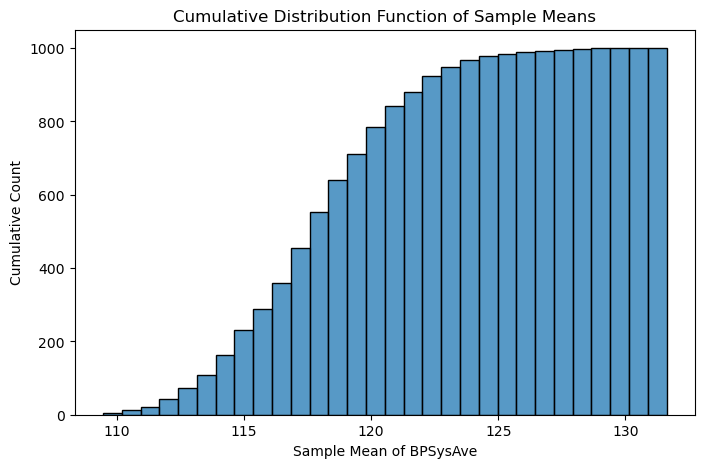

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(sm_series, bins=30, kde=False, cumulative=True)
plt.title("Cumulative Distribution Function of Sample Means")
plt.xlabel("Sample Mean of BPSysAve")
plt.ylabel("Cumulative Count")
plt.show()